In [49]:
library(dplyr)
library(ggplot2)
library(lubridate)
install.packages("keras3")
install.packages("tensorflow")
install.packages("reticulate")
library(keras)
fol=read.csv("C:/Users/jayan/Documents/Datascience/Raw_data/reservoir data.csv")
flow=read.csv("C:/Users/jayan/Documents/Datascience/Raw_data/inflow.csv")
swe=read.csv("C:/Users/jayan/Documents/Datascience/Raw_data/swedata.csv")
precip=read.csv("C:/Users/jayan/Documents/Datascience/Raw_data/rainfall.csv",skip=2)


head(fol)
head(precip)
head(flow)

Installing package into 'C:/Users/jayan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)

Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"downloaded length 12919875 != reported length 14379015"
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
"URL 'https://cran.r-project.org/bin/windows/contrib/4.6/keras3_1.5.1.zip': Timeout of 60 seconds was reached"


Error in download.file(urls, destfiles, "libcurl", mode = "wb", ...) : 
  download from 'https://cran.r-project.org/bin/windows/contrib/4.6/keras3_1.5.1.zip' failed


Warning message in download.packages(pkgs, destdir = tmpd, available = available, :
"download of package 'keras3' failed"
Installing package into 'C:/Users/jayan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'tensorflow' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\jayan\AppData\Local\Temp\RtmpWa5NyE\downloaded_packages


Installing package into 'C:/Users/jayan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



...

Warning message:
"cannot remove prior installation of package 'reticulate'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\jayan\AppData\Local\R\win-library\4.6\00LOCK\reticulate\libs\x64\reticulate.dll to C:\Users\jayan\AppData\Local\R\win-library\4.6\reticulate\libs\x64\reticulate.dll: Permission denied"
Warning message:
"restored 'reticulate'"



The downloaded binary packages are in
	C:\Users\jayan\AppData\Local\Temp\RtmpWa5NyE\downloaded_packages


,DATE,STORAGE.AF,X,LK.EVAP.AF,X.1,DC.PUMP.CFS,X.2
,<chr>,<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>
1,04/2021,"359,049",NA,"2,636",NA,"3,947",
2,05/2021,"361,000",NA,"4,122",NA,"5,302",
3,06/2021,"288,402",NA,"4,388",NA,"5,565",
4,07/2021,"243,824",NA,"3,675",NA,"6,009",
5,08/2021,"233,573",NA,"2,836",NA,"5,422",
6,09/2021,"229,541",NA,"2,531",NA,"2,800",


,Date,Value
,<int>,<dbl>
1,202001,3.79
2,202002,0.13
3,202003,6.63
4,202004,3.52
5,202005,2.50
6,202006,0.27


,STATION_ID,DURATION,SENSOR_NUMBER,SENSOR_TYPE,DATE.TIME,OBS.DATE,VALUE,DATA_FLAG,UNITS
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,FOL,D,76,INFLOW,19900101 0000,19900101 0000,1240,,CFS
2,FOL,D,76,INFLOW,19900102 0000,19900102 0000,1370,,CFS
3,FOL,D,76,INFLOW,19900103 0000,19900103 0000,1253,,CFS
4,FOL,D,76,INFLOW,19900104 0000,19900104 0000,1808,,CFS
5,FOL,D,76,INFLOW,19900105 0000,19900105 0000,1044,,CFS
6,FOL,D,76,INFLOW,19900106 0000,19900106 0000,1170,,CFS


In [56]:
precip$Value = as.numeric(precip$Value)
fol$STORAGE.AF = as.numeric(fol$STORAGE.AF)
dim(fol)
dim(precip)
#cor(precip$Value,fol$STORAGE.AF)

[1] 61  7

[1] 72  2

In [57]:
na.omit(c(fol,flow,swe))

$DATE
 [1] "04/2021" "05/2021" "06/2021" "07/2021" "08/2021" "09/2021" "10/2021"
 [8] "11/2021" "12/2021" "01/2022" "02/2022" "03/2022" "04/2022" "05/2022"
[15] "06/2022" "07/2022" "08/2022" "09/2022" "10/2022" "11/2022" "12/2022"
[22] "01/2023" "02/2023" "03/2023" "04/2023" "05/2023" "06/2023" "07/2023"
[29] "08/2023" "09/2023" "10/2023" "11/2023" "12/2023" "01/2024" "02/2024"
[36] "03/2024" "04/2024" "05/2024" "06/2024" "07/2024" "08/2024" "09/2024"
[43] "10/2024" "11/2024" "12/2024" "01/2025" "02/2025" "03/2025" "04/2025"
[50] "05/2025" "06/2025" "07/2025" "08/2025" "09/2025" "10/2025" "11/2025"
[57] "12/2025" "01/2026" "02/2026" "03/2026" "04/2026"

$STORAGE.AF
 [1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[26] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[51] NA NA NA NA NA NA NA NA NA NA NA

$X
 [1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[26] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[51] NA NA NA NA NA NA NA NA NA NA NA

$LK.EVAP.AF
 [1] "2,636" "4,122" "4,388" "3,675" "2,836" "2,531" "1,371" "482"   "317"  
[10] "881"   "1,783" "2,017" "2,634" "5,849" "6,234" "6,589" "5,098" "3,441"
[19] "2,077" "488"   "292"   "716"   "972"   "1,023" "3,753" "4,576" "5,782"
[28] "8,013" "6,460" "4,034" "2,501" "1,327" "674"   "182"   "647"   "1,603"
[37] "2,862" "6,030" "7,791" "8,128" "5,818" "4,209" "3,078" "690"   "361"  
[46] "861"   "1,000" "1,381" "3,247" "6,502" "7,305" "6,871" "5,314" "3,578"
[55] "1,672" "696"   "240"   "787"   "736"   "3,217" "--"   

$X.1
 [1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[26] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[51] NA NA NA NA NA NA NA NA NA NA NA

$DC.PUMP.CFS
 [1] "3,947" "5,302" "5,565" "6,009" "5,422" "2,800" "1,169" "1,256" "506"  
[10] "1,257" "1,801" "2,367" "3,041" "4,753" "5,600" "5,782" "5,722" "4,747"
[19] "3,617" "1,705" "1,687" "1,961" "1,608" "1,573" "2,487" "5,184" "6,902"
[28] "8,483" "8,217" "6,858" "5,255" "2,887" "2,370" "1,975" "1,808" "2,125"
[37] "3,011" "5,827" "7,619" "8,880" "8,356" "7,440" "5,993" "3,427" "2,226"
[46] "2,143" "2,767" "2,258" "3,416" "6,320" "7,468" "6,534" "7,308" "6,267"
[55] "4,095" "2,561" "2,138" "2,420" "2,223" "3,474" "--"   

$X.2
 [1] ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  "r" "" 
[20] ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  "" 
[39] ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  ""  "" 
[58] ""  ""  ""  "" 

$STATION_ID
    [1] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
   [13] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
   [25] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
   [37] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
   [49] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
   [61] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
   [73] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
   [85] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
   [97] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [109] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [121] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [133] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [145] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [157] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [169] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [181] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [193] "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL" "FOL"
  [205

In [59]:
flow <- flow %>%
    mutate(merge_date=as.Date(ymd_hm(OBS.DATE)))
fol <- fol %>%
    
    mutate(merge_date= my(DATE),
          STORAGE.AF = gsub(",", "", STORAGE.AF))
swe <- swe %>%
    mutate(merge_date= ymd(Date))
precip <- precip %>% 
    mutate(merge_date = as.Date(ym(Date)))
final_df <- full_join(swe,fol,by="merge_date") %>% 
    full_join(flow,by="merge_date")
str(final_df)

'data.frame':	20386 obs. of  31 variables:
 $ X.x                       : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Date                      : chr  "1970-10-01" "1970-10-02" "1970-10-03" "1970-10-04" ...
 $ Air.Temp.Max..C.          : chr  "22" "24" "23" "23" ...
 $ Air.Temp.Min..C.          : chr  "5" "5" "6" "3" ...
 $ X24.hour.Total.Precip..mm.: chr  "0" "0" "0" "0" ...
 $ Season.Total.Precip..mm.  : chr  "0.0" "0.0" "0.0" "0.0" ...
 $ X..of.Precip.as.Snow      : chr  "--" "--" "--" "--" ...
 $ X..of.Precip.as.Rain      : chr  "--" "--" "--" "--" ...
 $ New.Snow..cm.             : chr  "0.0" "0.0" "0.0" "0.0" ...
 $ Season.Total.Snow..cm.    : chr  "0.0" "0.0" "0.0" "0.0" ...
 $ Snowpack.depth..cm.       : chr  "0.0" "0.0" "0.0" "0.0" ...
 $ Snow.Water.Equivalent..cm.: chr  "0.0" "0.0" "0.0" "0.0" ...
 $ Remarks                   : chr  "" "" "" "" ...
 $ Unnamed..12               : num  NA NA NA NA NA NA NA NA NA NA ...
 $ merge_date                : Date, format: "1970-10-01" "1970-10-02" 

Warning message:
"NAs introduced by coercion"
Warning message:
"NAs introduced by coercion"
Warning message:
"NAs introduced by coercion"
Warning message:
"NAs introduced by coercion"
Warning message in log(final_df$VALUE):
"NaNs produced"
Warning message in log(SWE_lag30):
"NaNs produced"



Call:
lm(formula = VALUE ~ Snow.Water.Equivalent..cm. + average_temperature, 
    data = final_df)

Residuals:
   Min     1Q Median     3Q    Max 
-78210  -1458   -645    308 103438 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)                2537.194     91.715  27.664  < 2e-16 ***
Snow.Water.Equivalent..cm.   55.674      1.339  41.576  < 2e-16 ***
average_temperature         -36.112      7.321  -4.933 8.28e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4354 on 8157 degrees of freedom
  (12226 observations deleted due to missingness)
Multiple R-squared:  0.2323,	Adjusted R-squared:  0.2321 
F-statistic:  1234 on 2 and 8157 DF,  p-value: < 2.2e-16



Call:
lm(formula = logvalue ~ log(SWE_lag30), data = final_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.7139 -0.6394 -0.0070  0.6009  3.8289 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)     7.62614    0.03074  248.08   <2e-16 ***
log(SWE_lag30)  0.51557    0.02310   22.32   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9021 on 2840 degrees of freedom
  (2049 observations deleted due to missingness)
Multiple R-squared:  0.1492,	Adjusted R-squared:  0.1489 
F-statistic: 497.9 on 1 and 2840 DF,  p-value: < 2.2e-16


,2.5 %,97.5 %
(Intercept),7.5658658,7.686419
log(SWE_lag30),0.4702708,0.560878


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 1977 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 1977 rows containing missing values or values outside the scale range
(`geom_point()`)."


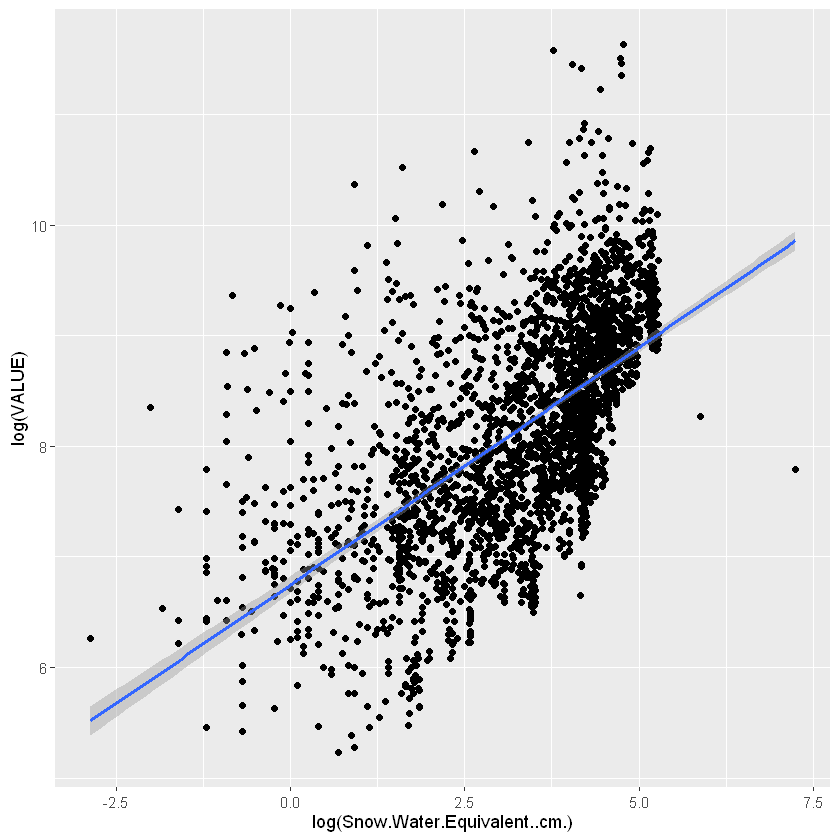

In [60]:



final_df$VALUE = as.numeric(final_df$VALUE)
final_df$Snow.Water.Equivalent..cm. = as.numeric(final_df$Snow.Water.Equivalent..cm.)
final_df$Air.Temp.Max..C. = as.numeric(final_df$Air.Temp.Max..C.)
final_df$Air.Temp.Min..C. = as.numeric(final_df$Air.Temp.Min..C.)
final_df$net_inflow = final_df$inflow
final_df$average_temperature = (final_df$Air.Temp.Max..C.+final_df$Air.Temp.Min..C.)/2
final_df$logSWE = log(final_df$Snow.Water.Equivalent..cm.)
final_df$logvalue = log(final_df$VALUE)+0.0001
model <- lm(VALUE~Snow.Water.Equivalent..cm.+average_temperature,data=final_df)
best_lag=0
best_corr=0
for (i in 1:100){final_df <- final_df %>%
    arrange(merge_date) %>%
    mutate(SWE_lag30 = lag(Snow.Water.Equivalent..cm., i))
    model_lag <- lm(VALUE ~ SWE_lag30,data=final_df)
    rsquared=summary(model_lag)$r.squared
    if(summary(model_lag)$r.squared > best_corr){
        
        best_corr=rsquared
        best_lag=i
        }
    }
final_df <- final_df %>%
  filter(Snow.Water.Equivalent..cm. > 0)
final_df <- final_df %>%
    arrange(merge_date) %>%
    mutate(SWE_lag30 = log(lag(Snow.Water.Equivalent..cm., best_lag)+0.001))
    model_lag <- lm(VALUE ~ SWE_lag30,data=final_df)
model_lag <- lm(logvalue ~ log(SWE_lag30),data=final_df)
summary(model)
summary(model_lag)
confint(model_lag)
pred=predict(model)

ggplot(final_df,aes(x=log(Snow.Water.Equivalent..cm.),y=log(VALUE)))+
geom_point()+
geom_smooth(method="lm")

In [46]:
library(mgcv)
model <- lm(VALUE~SWE_lag30,data=final_df)
data = fitted(model)
summary(model)


best_lag
dim(final_df)
thegam <- gam(VALUE~s(SWE_lag30),data=final_df)
summary(thegam)


Call:
lm(formula = VALUE ~ SWE_lag30, data = final_df)

Residuals:
   Min     1Q Median     3Q    Max 
 -9436  -3280  -1581   1089 104717 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   251.49     348.53   0.722    0.471    
SWE_lag30    1640.59      96.21  17.052   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 7098 on 2912 degrees of freedom
  (1977 observations deleted due to missingness)
Multiple R-squared:  0.09078,	Adjusted R-squared:  0.09047 
F-statistic: 290.8 on 1 and 2912 DF,  p-value: < 2.2e-16


[1] 7

[1] 4891   35


Family: gaussian 
Link function: identity 

Formula:
VALUE ~ s(SWE_lag30)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   5755.5      128.2   44.88   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
               edf Ref.df     F p-value    
s(SWE_lag30) 8.476   8.93 51.14  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.135   Deviance explained = 13.7%
GCV = 4.8078e+07  Scale est. = 4.7922e+07  n = 2914

In [45]:
library(boot)
str(final_df)

'data.frame':	4891 obs. of  35 variables:
 $ X.x                       : int  60 62 63 64 67 69 71 74 76 78 ...
 $ Date                      : chr  "1970-11-30" "1970-12-02" "1970-12-03" "1970-12-04" ...
 $ Air.Temp.Max..C.          : num  -3 -6 -1 1 2 2 5 -3 -5 -6 ...
 $ Air.Temp.Min..C.          : num  -4 -8 -6 -1 -2 -11 -7 -8 -9 -12 ...
 $ X24.hour.Total.Precip..mm.: chr  "109" "47" "20" "60" ...
 $ Season.Total.Precip..mm.  : chr  "523.0" "607.0" "627.0" "687.0" ...
 $ X..of.Precip.as.Snow      : chr  "--" "--" "--" "--" ...
 $ X..of.Precip.as.Rain      : chr  "--" "--" "--" "--" ...
 $ New.Snow..cm.             : chr  "94.0" "76.2" "21.6" "96.0" ...
 $ Season.Total.Snow..cm.    : chr  "204.4" "280.6" "302.2" "398.2" ...
 $ Snowpack.depth..cm.       : chr  "94.0" "143.5" "149.9" "212.1" ...
 $ Snow.Water.Equivalent..cm.: num  16 27.7 30 39.2 39.9 44.4 44.5 43.2 50.5 55.4 ...
 $ Remarks                   : chr  "" "" "" "" ...
 $ Unnamed..12               : num  NA NA NA NA NA NA NA

In [47]:
?sd()


sd {stats},R Documentation
x,a numeric vector or an R object but not a factor coercible to numeric by as.double(x).
na.rm,logical. Should missing values be removed?
